In [1]:
#Data Cleaning & Preprocessing – Handling missing values, duplicates, inconsistent formats, and feature engineering.

In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("/content/books_data (2).csv")

In [4]:
print(df.head())
print(df.info())

                                   title  price rating  \
0                   A Light in the Attic  51.77  Three   
1                     Tipping the Velvet  53.74    One   
2                             Soumission  50.10    One   
3                          Sharp Objects  47.82   Four   
4  Sapiens: A Brief History of Humankind  54.23   Five   

                                                link  
0  https://books.toscrape.com/catalogue/a-light-i...  
1  https://books.toscrape.com/catalogue/tipping-t...  
2  https://books.toscrape.com/catalogue/soumissio...  
3  https://books.toscrape.com/catalogue/sharp-obj...  
4  https://books.toscrape.com/catalogue/sapiens-a...  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   title   1000 non-null   object 
 1   price   1000 non-null   float64
 2   rating  1000 non-null   object 
 3   link    1000 non-null   ob

In [5]:
#Handling Missing Values

In [6]:
print(df.isnull().sum())

title     0
price     0
rating    0
link      0
dtype: int64


In [7]:
df = df.dropna(axis=1, thresh=len(df)*0.6)

In [8]:
print(df)

                                                 title  price rating  \
0                                 A Light in the Attic  51.77  Three   
1                                   Tipping the Velvet  53.74    One   
2                                           Soumission  50.10    One   
3                                        Sharp Objects  47.82   Four   
4                Sapiens: A Brief History of Humankind  54.23   Five   
..                                                 ...    ...    ...   
995  Alice in Wonderland (Alice's Adventures in Won...  55.53    One   
996   Ajin: Demi-Human, Volume 1 (Ajin: Demi-Human #1)  57.06   Four   
997  A Spy's Devotion (The Regency Spies of London #1)  16.97   Five   
998                1st to Die (Women's Murder Club #1)  53.98    One   
999                 1,000 Places to See Before You Die  26.08   Five   

                                                  link  
0    https://books.toscrape.com/catalogue/a-light-i...  
1    https://books.to

In [9]:
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

In [10]:
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipython-input-3147412023.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [11]:
#Handling Duplicate Records

In [12]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [13]:
df = df.drop_duplicates()


In [14]:
#Handling Inconsistent Formats

In [15]:
df.columns = df.columns.str.lower().str.replace(" ", "_")

In [16]:
df['rating'] = df['rating'].str.lower().str.strip()

In [17]:
df['price'] = df['price'].replace('[₹$,]', '', regex=True).astype(float)

In [18]:
print(df['price'] )

0      51.77
1      53.74
2      50.10
3      47.82
4      54.23
       ...  
995    55.53
996    57.06
997    16.97
998    53.98
999    26.08
Name: price, Length: 1000, dtype: float64


In [19]:
df['publish_date'] = pd.to_datetime(df.get('publish_date'), errors='coerce')

In [20]:
#Feature Engineering

In [21]:
df['price_category'] = pd.cut(
    df['price'],bins=[0, 300, 600, 1000, np.inf],labels=['Low', 'Medium', 'High', 'Premium'])

In [22]:
df['publish_year'] = pd.to_datetime(df['publish_date'], errors='coerce').dt.year

In [23]:
df['title_length'] = df['title'].apply(len)

In [24]:
df = pd.get_dummies(df, columns=['rating'], drop_first=True)

In [25]:
print(df.head())
print(df.isnull().sum())

                                   title  price  \
0                   A Light in the Attic  51.77   
1                     Tipping the Velvet  53.74   
2                             Soumission  50.10   
3                          Sharp Objects  47.82   
4  Sapiens: A Brief History of Humankind  54.23   

                                                link publish_date  \
0  https://books.toscrape.com/catalogue/a-light-i...         None   
1  https://books.toscrape.com/catalogue/tipping-t...         None   
2  https://books.toscrape.com/catalogue/soumissio...         None   
3  https://books.toscrape.com/catalogue/sharp-obj...         None   
4  https://books.toscrape.com/catalogue/sapiens-a...         None   

  price_category  publish_year  title_length  rating_four  rating_one  \
0            Low           NaN            20        False       False   
1            Low           NaN            18        False        True   
2            Low           NaN            10        False  

In [26]:
df.to_csv("cleaned_books_data.csv", index=False)
print("Cleaned dataset saved successfully")

Cleaned dataset saved successfully


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
df = pd.read_csv("/content/cleaned_books_data.csv")



In [29]:
df.head()

,title,price,link,publish_date,price_category,publish_year,title_length,rating_four,rating_one,rating_three,rating_two
0,A Light in the Attic,51.77,https://books.toscrape.com/catalogue/a-light-i...,NaN,Low,NaN,20,False,False,True,False
1,Tipping the Velvet,53.74,https://books.toscrape.com/catalogue/tipping-t...,NaN,Low,NaN,18,False,True,False,False
2,Soumission,50.10,https://books.toscrape.com/catalogue/soumissio...,NaN,Low,NaN,10,False,True,False,False
3,Sharp Objects,47.82,https://books.toscrape.com/catalogue/sharp-obj...,NaN,Low,NaN,13,True,False,False,False
4,Sapiens: A Brief History of Humankind,54.23,https://books.toscrape.com/catalogue/sapiens-a...,NaN,Low,NaN,37,False,False,False,False


In [30]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


Rows: 1000
Columns: 11


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           1000 non-null   object 
 1   price           1000 non-null   float64
 2   link            1000 non-null   object 
 3   publish_date    0 non-null      float64
 4   price_category  1000 non-null   object 
 5   publish_year    0 non-null      float64
 6   title_length    1000 non-null   int64  
 7   rating_four     1000 non-null   bool   
 8   rating_one      1000 non-null   bool   
 9   rating_three    1000 non-null   bool   
 10  rating_two      1000 non-null   bool   
dtypes: bool(4), float64(3), int64(1), object(3)
memory usage: 58.7+ KB


In [32]:
df.describe()

,price,publish_date,publish_year,title_length
count,1000.00000,0.0,0.0,1000.000000
mean,35.07035,NaN,NaN,39.119000
std,14.44669,NaN,NaN,25.782893
min,10.00000,NaN,NaN,2.000000
25%,22.10750,NaN,NaN,19.000000
50%,35.98000,NaN,NaN,35.000000
75%,47.45750,NaN,NaN,53.000000
max,59.99000,NaN,NaN,205.000000


In [33]:
df.describe(include='object')

,title,link,price_category
count,1000,1000,1000
unique,999,1000,1
top,The Star-Touched Queen,https://books.toscrape.com/catalogue/1000-plac...,Low
freq,2,1,1000


In [34]:
 #Exploratory Data Analysis & Visualization – Graphical and statistical summaries to uncover insights.


In [35]:
def get_rating(row):
    if row['rating_four']: return 4
    if row['rating_one']: return 1
    if row['rating_three']: return 3
    if row['rating_two']: return 2
    return 5

In [36]:
df['rating'] = df.apply(get_rating, axis=1)
plt.style.use('ggplot')

In [37]:
print("Summary Statistics")
print(df[['price', 'title_length', 'rating']].describe())

Summary Statistics
            price  title_length       rating
count  1000.00000   1000.000000  1000.000000
mean     35.07035     39.119000     2.923000
std      14.44669     25.782893     1.434967
min      10.00000      2.000000     1.000000
25%      22.10750     19.000000     2.000000
50%      35.98000     35.000000     3.000000
75%      47.45750     53.000000     4.000000
max      59.99000    205.000000     5.000000


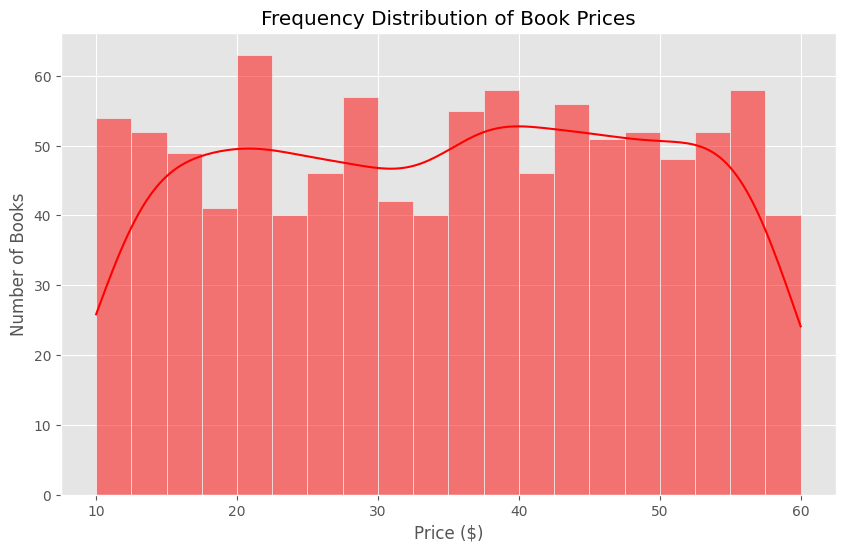

In [38]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=20, kde=True, color='Red')
plt.title('Frequency Distribution of Book Prices')
plt.xlabel('Price ($)')
plt.ylabel('Number of Books')
plt.show()

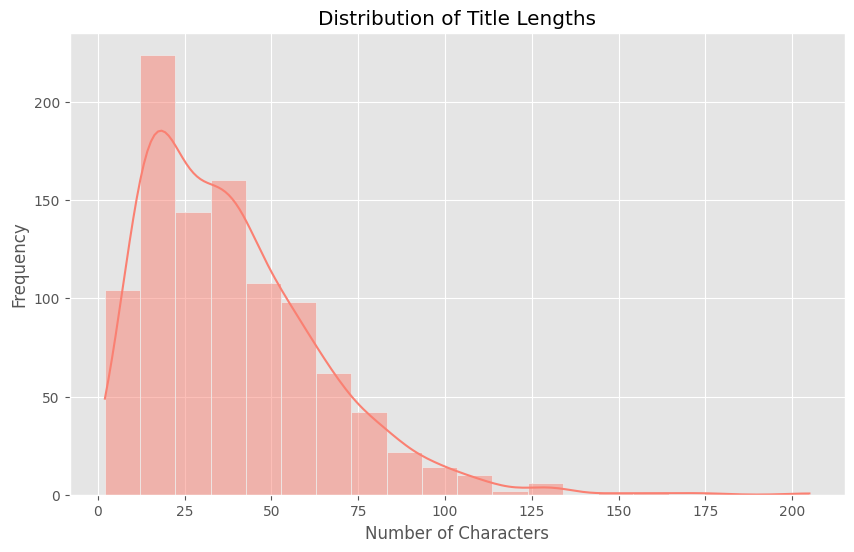

In [39]:
plt.figure(figsize=(10, 6))
sns.histplot(df['title_length'], bins=20, kde=True, color='salmon')
plt.title('Distribution of Title Lengths')
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')
plt.show()

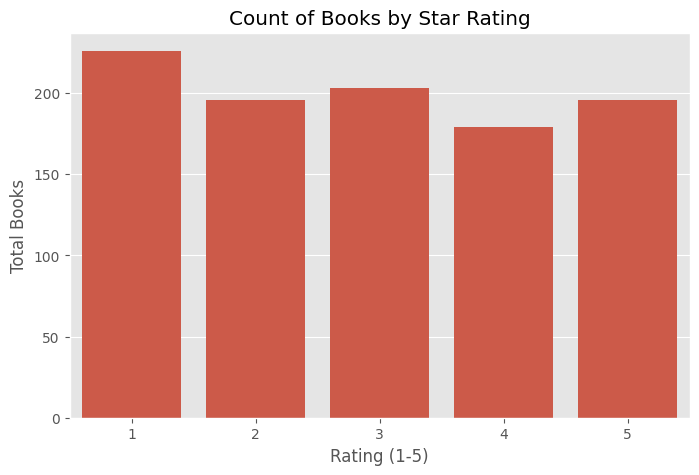

In [40]:
plt.figure(figsize=(8, 5))
rating_counts = df['rating'].value_counts().sort_index()
sns.barplot(x=rating_counts.index, y=rating_counts.values)
plt.title('Count of Books by Star Rating')
plt.xlabel('Rating (1-5)')
plt.ylabel('Total Books')
plt.show()

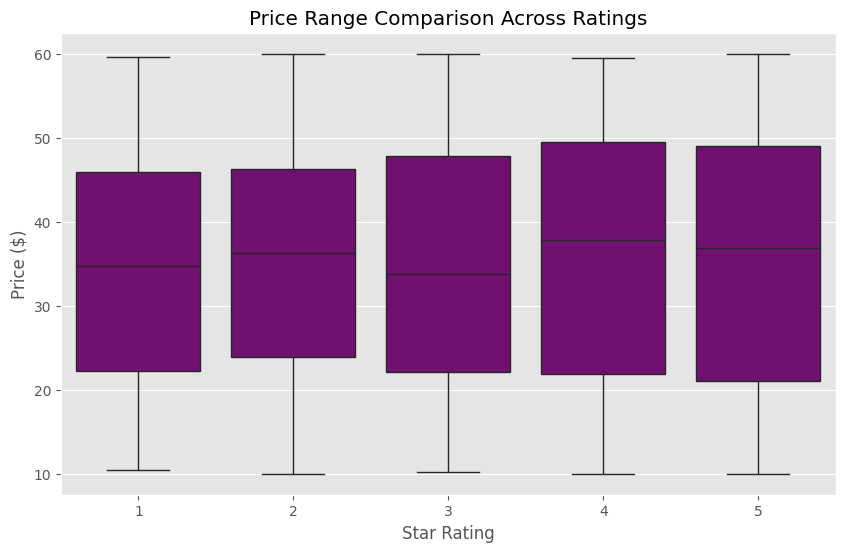

In [41]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='rating', y='price', data=df, color='Purple')
plt.title('Price Range Comparison Across Ratings')
plt.xlabel('Star Rating')
plt.ylabel('Price ($)')
plt.show()

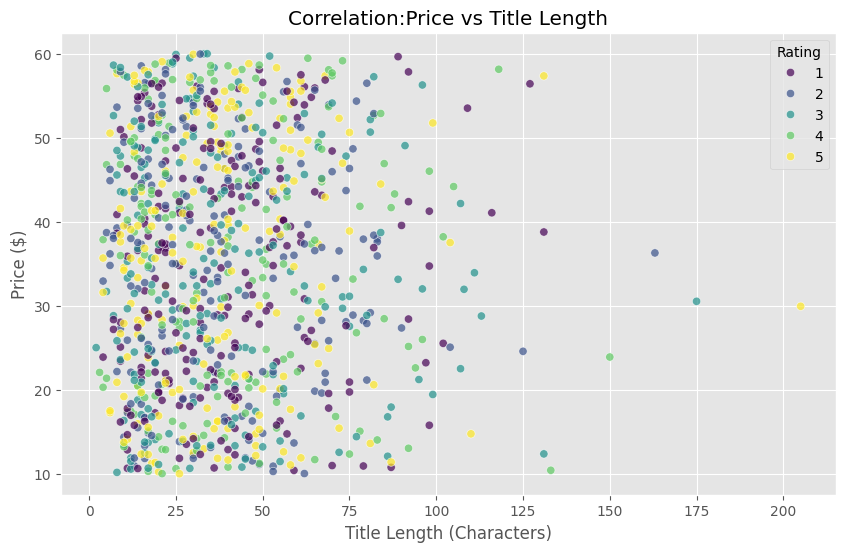

In [42]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='title_length', y='price', data=df, hue='rating', palette='viridis', alpha=0.7)
plt.title('Correlation:Price vs Title Length')
plt.xlabel('Title Length (Characters)')
plt.ylabel('Price ($)')
plt.legend(title='Rating')
plt.show()

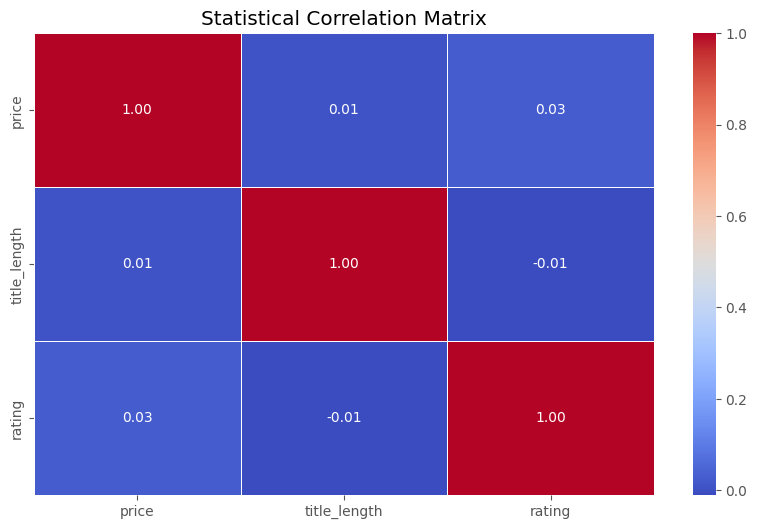

In [43]:
plt.figure(figsize=(10, 6))
corr_matrix = df[['price', 'title_length', 'rating']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Statistical Correlation Matrix')
plt.show()

In [44]:
# Model Building & Evaluation – Develop a predictive model (clustering or regression/classification model)

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, silhouette_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans

In [46]:
def get_rating(row):
    if row['rating_four']: return 4
    if row['rating_one']: return 1
    if row['rating_three']: return 3
    if row['rating_two']: return 2
    return 5
df['rating'] = df.apply(get_rating, axis=1)

print("Data Prepared")

Data Prepared


In [47]:
X = df[['title_length', 'rating']]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

reg_model = LinearRegression()
reg_model.fit(X_train, y_train)

y_pred = reg_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Regression Evaluation")
print("Mean Squared Error: {mse:.2f}")
print("R-squared Score: {r2:.4f}")



Regression Evaluation
Mean Squared Error: {mse:.2f}
R-squared Score: {r2:.4f}


In [48]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X = df[['title_length', 'rating']]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"Model R-squared: {r2:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"Formula: Price = ({model.coef_[0]:.4f} * Title Length) + ({model.coef_[1]:.4f} * Rating) + {model.intercept_:.4f}")

Model R-squared: -0.0118
Mean Squared Error: 212.5368
Formula: Price = (0.0158 * Title Length) + (0.3639 * Rating) + 33.6101


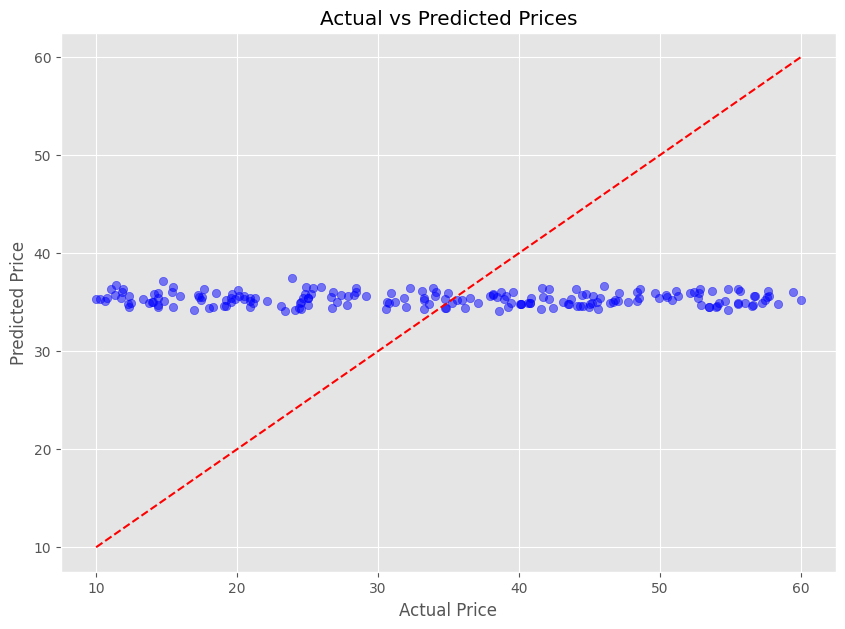

In [49]:
plt.figure(figsize=(10,7))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--r')
plt.title('Actual vs Predicted Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.show()

In [50]:
X_clf = df[['price', 'title_length']]
y_clf = df['rating']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

clf_model = RandomForestClassifier(n_estimators=100, random_state=42)
clf_model.fit(X_train_c, y_train_c)

y_pred_c = clf_model.predict(X_test_c)

accuracy = accuracy_score(y_test_c, y_pred_c)
print("Classification Evaluation")
print("Accuracy: {accuracy:.2%}")
print("\nClassification Report:")
print(classification_report(y_test_c, y_pred_c))



Classification Evaluation
Accuracy: {accuracy:.2%}

Classification Report:
              precision    recall  f1-score   support

           1       0.24      0.30      0.27        40
           2       0.18      0.24      0.20        38
           3       0.22      0.17      0.19        42
           4       0.26      0.19      0.22        36
           5       0.31      0.30      0.30        44

    accuracy                           0.24       200
   macro avg       0.24      0.24      0.24       200
weighted avg       0.24      0.24      0.24       200



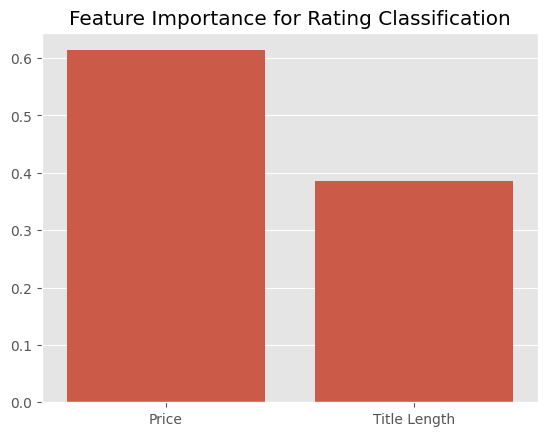

In [51]:
importances = clf_model.feature_importances_
sns.barplot(x=['Price', 'Title Length'], y=importances)
plt.title('Feature Importance for Rating Classification')
plt.show()

In [52]:
X_clust = df[['price', 'title_length', 'rating']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clust)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

score = silhouette_score(X_scaled, df['cluster'])
print("Clustering Evaluation")
print("Silhouette Score: {score:.4f}")

print("\nCluster Characteristics (Means):")
print(df.groupby('cluster')[['price', 'title_length', 'rating']].mean())

Clustering Evaluation
Silhouette Score: {score:.4f}

Cluster Characteristics (Means):
             price  title_length    rating
cluster                                   
0        21.470674     29.129534  2.816062
1        47.347550     28.710396  3.185644
2        36.448857     77.504762  2.614286


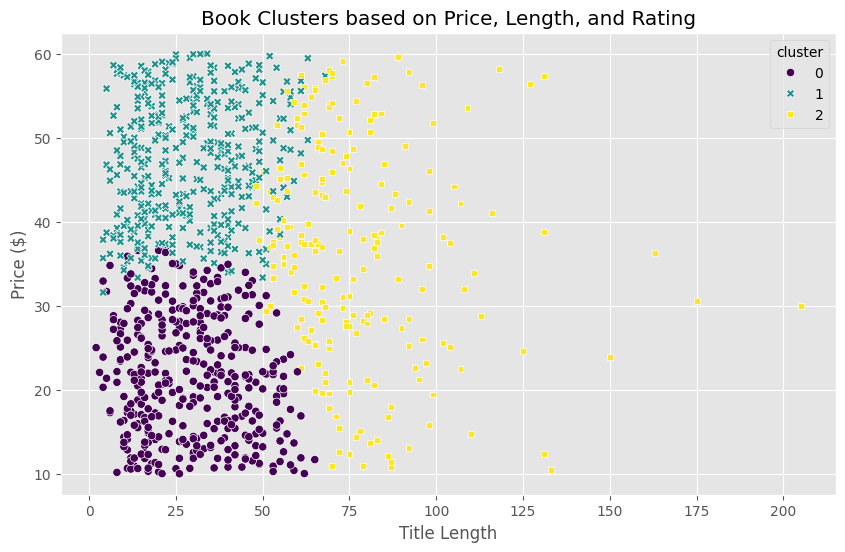

In [53]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='title_length', y='price', hue='cluster', data=df, palette='viridis', style='cluster')
plt.title('Book Clusters based on Price, Length, and Rating')
plt.xlabel('Title Length')
plt.ylabel('Price ($)')
plt.show()

In [54]:
#Interactive Dashboard

In [55]:
!pip install streamlit -q
!pip install pyarrow -q

In [56]:
%%writefile app.py
import streamlit as st
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

st.set_page_config(page_title="Ultimate Book Analytics Dashboard", layout="wide")

@st.cache_data
def load_data():
    df = pd.read_csv('/content/cleaned_books_data.csv')

    def get_rating(row):
        if row['rating_four']: return 4
        if row['rating_one']: return 1
        if row['rating_three']: return 3
        if row['rating_two']: return 2
        return 5 # Assume rest are 5 stars

    df['rating_score'] = df.apply(get_rating, axis=1)
    return df

df = load_data()

st.sidebar.header(" Control Panel")
st.sidebar.markdown("Use these filters to update all visuals (Sync Slicers).")

# Filter 1: Price Range Slider
min_p, max_p = float(df['price'].min()), float(df['price'].max())
price_range = st.sidebar.slider("Select Price Range ($)", min_p, max_p, (min_p, max_p))

# Filter 2: Price Category Multi-select
categories = sorted(df['price_category'].unique())
selected_cat = st.sidebar.multiselect("Price Categories", categories, default=categories)

# Filter 3: Rating Selection
ratings = sorted(df['rating_score'].unique())
selected_ratings = st.sidebar.multiselect("Book Ratings", ratings, default=ratings)

filtered_df = df[
    (df['price'] >= price_range[0]) &
    (df['price'] <= price_range[1]) &
    (df['price_category'].isin(selected_cat)) &
    (df['rating_score'].isin(selected_ratings))]

st.sidebar.info("Bookmark: Dashboard filtered for 2024 Inventory Analysis.")

if st.sidebar.button("🔄 Reset All Filters"):
    st.rerun()

st.title("📚 Comprehensive Books Insights Dashboard")
st.markdown("---")

# SECTION 1: KPIs (Key Performance Indicators)
kpi1, kpi2, kpi3, kpi4 = st.columns(4)
with kpi1:
    st.metric("Total Inventory", f"{len(filtered_df)} Books")
with kpi2:
    st.metric("Avg. Price", f"${filtered_df['price'].mean():.2f}")
with kpi3:
    st.metric("Highest Price", f"${filtered_df['price'].max():.2f}")
with kpi4:
    avg_len = filtered_df['title_length'].mean() if not filtered_df.empty else 0
    st.metric("Avg. Title Length", f"{int(avg_len)} Chars")

st.divider()

# SECTION 2: PRICE CATEGORY DISTRIBUTION (LOW, MEDIUM, HIGH)
st.subheader("Price Category Analysis (Low, Medium, High)")
col_a, col_b = st.columns(2)

with col_a:
    st.markdown("Book Counts by Category")
    cat_counts = filtered_df['price_category'].value_counts().reset_index()
    cat_counts.columns = ['Category', 'Count']

    fig_cat_bar = px.bar(cat_counts, x='Category', y='Count',
                         color='Category',
                         color_discrete_map={'Low': '#636EFA', 'Medium': '#EF553B', 'High': '#00CC96'},
                         text_auto=True)
    st.plotly_chart(fig_cat_bar, use_container_width=True)

with col_b:
    st.markdown("Price Spread within Categories")
    fig_cat_box = px.box(filtered_df, x="price_category", y="price",
                         color="price_category",
                         color_discrete_map={'Low': '#636EFA', 'Medium': '#EF553B', 'High': '#00CC96'},
                         labels={'price_category': 'Category', 'price': 'Price ($)'})
    st.plotly_chart(fig_cat_box, use_container_width=True)

st.divider()

# SECTION 3: RATINGS & FREQUENCY
col1, col2 = st.columns(2)

with col1:
    st.subheader("Market Share by Category")
    fig_pie = px.pie(filtered_df, names='price_category',
                     hole=0.4,
                     color='price_category',
                     color_discrete_map={'Low': '#636EFA', 'Medium': '#EF553B', 'High': '#00CC96'})
    st.plotly_chart(fig_pie, use_container_width=True)

with col2:
    st.subheader("Ratings Distribution")
    rating_counts = filtered_df['rating_score'].value_counts().reset_index()
    rating_counts.columns = ['Rating', 'Count']
    fig_rating = px.bar(rating_counts, x="Rating", y="Count",
                        color="Rating", color_continuous_scale='Viridis')
    st.plotly_chart(fig_rating, use_container_width=True)

st.divider()

# SECTION 4: AI INSIGHTS & LEADERBOARD
col5, col6 = st.columns([1.5, 1])

with col5:
    st.subheader("AI Insights: Title Length vs Price Trend")
    st.info("Visualizing the correlation using OLS Linear Regression.")
    if not filtered_df.empty:
        fig_trend = px.scatter(filtered_df, x="title_length", y="price",
                         trendline="ols",
                         color="price_category",
                         hover_name="title",
                         labels={'title_length': 'Length of Title', 'price': 'Price ($)'})
        st.plotly_chart(fig_trend, use_container_width=True)
    else:
        st.warning("No data available for AI Trendline.")

with col6:
    st.subheader("🏆 Top 10 Most Expensive")
    top_10 = filtered_df.nlargest(10, 'price')[['title', 'price']]
    fig_top = px.bar(top_10, x='price', y='title', orientation='h',
                     color='price', color_continuous_scale='Reds',
                     labels={'price': 'Price ($)', 'title': 'Title'})
    fig_top.update_layout(yaxis={'categoryorder':'total ascending'})
    st.plotly_chart(fig_top, use_container_width=True)

st.divider()

# SECTION 5: DRILL THROUGH & REPORTING
with st.expander("🔍 Drill Through: View Detailed Raw Data"):
    st.write("Below is the filtered dataset based on your sidebar selections.")
    st.dataframe(filtered_df, use_container_width=True)

    csv = filtered_df.to_csv(index=False).encode('utf-8')
    st.download_button(
        label="Download Detailed Report (CSV)",data=csv,
        file_name='final_filtered_report.csv',mime='text/csv',)

st.caption("Dashboard developed for Book Inventory Management | Data Source: cleaned_books_data.csv")

Overwriting app.py


In [57]:
# 1. Start streamlit in the background
!streamlit run app.py & npx localtunnel --port 8501 & curl ipv4.icanhazip.com

34.48.198.36
⠙⠹⠸

⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) 
  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.48.198.36:8501

  Stopping...
